In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

# Problem 1
## Dataset Generation

Write a function to **generate a training set** of size $m$
- randomly generate a weight vector $w \in \mathbb{R}^{10}$, normalize length
- generate a training set $\{(x_i , y_i)\}$ of size m
  - $x_i$: random vector in $\mathbb{R}^{10}$ from $\textbf{N}(0, I)$
  - $y_i$: $\{0, +1\}$ with $P[y = +1] = \sigma(w \cdot x_i)$ and $P[y = 0] = 1 - \sigma(w \cdot x_i)$

In [2]:
rng = np.random.default_rng(0)   # one generator drives the whole experiment


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [3]:
def sample_w():
    return rng.standard_normal(10)


print("raw draw:", np.round(sample_w(), 4))

raw draw: [ 0.1257 -0.1321  0.6404  0.1049 -0.5357  0.3616  1.304   0.9471 -0.7037
 -1.2654]


In [4]:
def generate_w_star():
    w = sample_w()                   # (a)i
    return w / np.linalg.norm(w)     # (a)ii


w_check = generate_w_star()
print("w*     =", np.round(w_check, 4))
print("||w*|| =", round(np.linalg.norm(w_check), 6))

w*     = [-0.2013  0.0133 -0.751  -0.0707 -0.4024 -0.2365 -0.1758 -0.1022  0.133
  0.3367]
||w*|| = 1.0


In [5]:
def generate_X(m):
    return rng.standard_normal((m, 10))   # same draw as (a)i, left un-normalized


print("X shape:", generate_X(5).shape)

X shape: (5, 10)


In [6]:
def gen_label(x, w):
    X = rng.uniform()                     # X ~ Uniform(0, 1)
    return 1 if X <= sigmoid(w @ x) else 0


# sanity check: a point strongly aligned with w* should label 1 most of the time
w_check = generate_w_star()
x_aligned = 3 * w_check
print("sigma(w* . x) =", round(sigmoid(w_check @ x_aligned), 4))
print("empirical rate:", np.mean([gen_label(x_aligned, w_check) for _ in range(2000)]))

sigma(w* . x) = 0.9526
empirical rate: 0.952


In [7]:
def generate_data(m):
    # returns the true w as well as X, Y data
    w = generate_w_star()                          # (a)
    X = generate_X(m)                              # (b)i
    Y = np.array([gen_label(x, w) for x in X])     # (b)ii
    return w, X, Y


w_demo, X_demo, Y_demo = generate_data(50)
print("||w*|| =", round(np.linalg.norm(w_demo), 6))
print("X shape:", X_demo.shape, " label counts:", np.bincount(Y_demo))

||w*|| = 1.0
X shape: (50, 10)  label counts: [29 21]


## Algorithm 1: logistic regression

The goal is to learn $w$.  Algorithm 1 is logistic
  regression (you may use the built-in method LogisticRegression for this. Use max_iter=1000).

In [8]:
from sklearn.linear_model import LogisticRegression

def algorithm1_logistic(X, Y):
    clf = LogisticRegression(max_iter=1000,fit_intercept=False)
    clf.fit(X, Y)
    return clf.coef_[0]

## Algorithm 2: gradient descent with square loss

Define square loss as
$$L_i(w^{(t)}) = \frac{1}{2} \left( \sigma(w^{(t)} \cdot x) - y_i \right)^2$$

  Algorithm 2 is
  gradient descent with respect to square loss (code this
  up yourself -- run for 1000 iterations, use step size eta = 0.01).

In [9]:
def algorithm2_gd(X, Y, eta=0.01, updates=1000):
    """1000 parameter updates. Batch size = m, so one update per full pass."""
    m, d = X.shape
    w = np.zeros(d)

    for _ in range(updates):
        s = sigmoid(X @ w)                       # sigma_i for every point
        grad = X.T @ ((s - Y) * s * (1 - s)) / m
        w = w - eta * grad

    return w

## Algorithm 3: stochastic gradient descent with square loss
Similar to gradient descent, except we use the gradient at a single random training point every iteration.

In [10]:
def algorithm3_sgd(X, Y, eta=0.01, updates=1000):
    """1000 parameter updates. Batch size = 1, so m updates per full pass."""
    m, d = X.shape
    w = np.zeros(d)
    idx = rng.integers(0, m, size=updates)       # one random point per iteration

    for t in idx:
        s = sigmoid(X[t] @ w)
        grad = (s - Y[t]) * s * (1 - s) * X[t]
        w = w - eta * grad

    return w

## Evaluation

Measure error $\|w - \hat{w}\|_2$ for each method at different sample size. For any
  fixed value of $m$, choose many different $w$'s and average the
  values $\|w - 
  \hat{w}\|_2$ for Algorithms 1, 2 and 3.  Plot the results
  for for each algorithm as you make $m$ large (use $m=50, 100, 150, 200, 250$).
  Also record, for each algorithm, the time taken to run the overall experiment.

In [11]:
sizes = [50, 100, 150, 200, 250]
trials = 100
algorithms = {
    "Algorithm 1: logistic regression": algorithm1_logistic,
    "Algorithm 2: GD (square loss)": algorithm2_gd,
    "Algorithm 3: SGD (square loss)": algorithm3_sgd,
}

errors = {name: [] for name in algorithms}
elapsed = {name: 0.0 for name in algorithms}

for m in sizes:
    batch = {name: [] for name in algorithms}
    for _ in range(trials):
        w_star, X, Y = generate_data(m)          # one dataset, all three algorithms
        for name, fit in algorithms.items():
            start = time.perf_counter()
            w_prime = fit(X, Y)
            elapsed[name] += time.perf_counter() - start
            batch[name].append(np.linalg.norm(w_star - w_prime))
    for name in algorithms:
        errors[name].append(np.mean(batch[name]))

print(f"{'m':>5}" + "".join(f"{name.split(':')[0]:>16}" for name in algorithms))
for i, m in enumerate(sizes):
    print(f"{m:>5}" + "".join(f"{errors[name][i]:>16.4f}" for name in algorithms))

print()
for name in algorithms:
    print(f"{name:35s} total time over the experiment: {elapsed[name]:.3f} s")

    m     Algorithm 1     Algorithm 2     Algorithm 3
   50          1.0861          0.7291          0.7298
  100          0.7319          0.6694          0.6740
  150          0.6009          0.6619          0.6667
  200          0.5108          0.6614          0.6661
  250          0.4550          0.6557          0.6625

Algorithm 1: logistic regression    total time over the experiment: 0.443 s
Algorithm 2: GD (square loss)       total time over the experiment: 4.312 s
Algorithm 3: SGD (square loss)      total time over the experiment: 1.351 s


In [12]:
updates = 1000
print(f"Per run at {updates} updates (per-point gradient evaluations):")
print(f"{'m':>5}{'GD':>12}{'SGD':>10}{'ratio':>10}")
for m in sizes:
    print(f"{m:>5}{updates * m:>12,}{updates:>10,}{m:>9}x")

Per run at 1000 updates (per-point gradient evaluations):
    m          GD       SGD     ratio
   50      50,000     1,000       50x
  100     100,000     1,000      100x
  150     150,000     1,000      150x
  200     200,000     1,000      200x
  250     250,000     1,000      250x


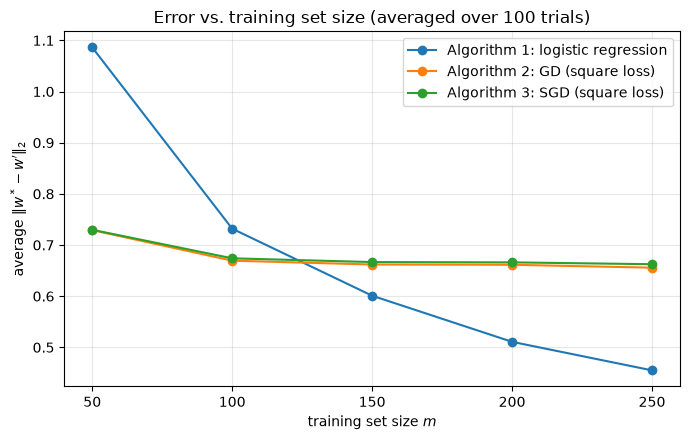

In [13]:
plt.figure(figsize=(7, 4.5))
for name in algorithms:
    plt.plot(sizes, errors[name], marker="o", label=name)

plt.xlabel("training set size $m$")
plt.ylabel(r"average $\|w^* - w'\|_2$")
plt.title(f"Error vs. training set size (averaged over {trials} trials)")
plt.xticks(sizes)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Problem 2

In [14]:
from sklearn import datasets
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [15]:
cancer = datasets.load_breast_cancer()

For each depth in $1, \dots, 5$, instantiate an AdaBoost classifier with the base learner set to be a decision tree of that depth (set `n_estimators=10` and `learning_rate=1`), and then record the 10-fold cross-validated error on the entire breast cancer data set. Plot the resulting curve of accuracy against base classifier depth. Use $101$ as your random state for both the base learner as well as the AdaBoost classifier every time.

In [16]:
depths = [1, 2, 3, 4, 5]
accuracy, cv_error = [], []

for d in depths:
    base = DecisionTreeClassifier(max_depth=d, random_state=101)
    try:                                          # sklearn >= 1.2
        boost = AdaBoostClassifier(estimator=base, n_estimators=10,
                                   learning_rate=1, random_state=101)
    except TypeError:                             # older sklearn
        boost = AdaBoostClassifier(base_estimator=base, n_estimators=10,
                                   learning_rate=1, random_state=101)

    scores = cross_val_score(boost, cancer.data, cancer.target, cv=10)
    accuracy.append(scores.mean())
    cv_error.append(1 - scores.mean())

print(f"{'depth':>6}{'CV accuracy':>14}{'CV error':>12}")
for d, a, e in zip(depths, accuracy, cv_error):
    print(f"{d:>6}{a:>14.4f}{e:>12.4f}")

best = depths[int(np.argmax(accuracy))]
print(f"\nBest base-learner depth: {best} (accuracy {max(accuracy):.4f})")

 depth   CV accuracy    CV error
     1        0.9508      0.0492
     2        0.9508      0.0492
     3        0.9648      0.0352
     4        0.9579      0.0421
     5        0.9684      0.0316

Best base-learner depth: 5 (accuracy 0.9684)


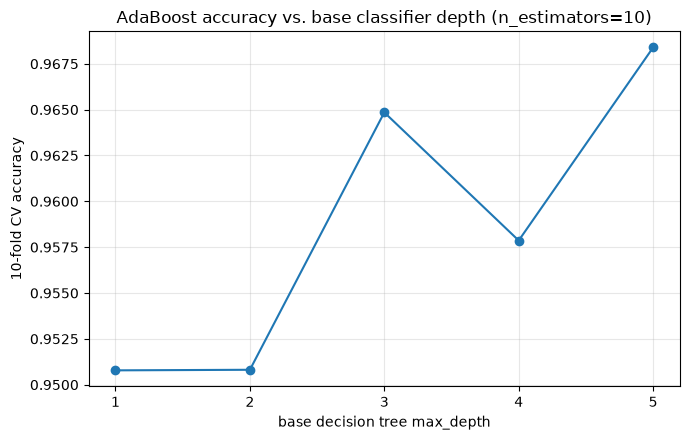

In [17]:
plt.figure(figsize=(7, 4.5))
plt.plot(depths, accuracy, marker="o", color="tab:blue")

plt.xlabel("base decision tree max_depth")
plt.ylabel("10-fold CV accuracy")
plt.title("AdaBoost accuracy vs. base classifier depth (n_estimators=10)")
plt.xticks(depths)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()